# SVM Baseline (v1)

SVM with RBF kernel on statistical features (RMS, MAV, WL, ZC, SSC, histogram). 120 features per window.

Runs all main scenarios for full baseline comparison.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

from config import MODELS_DIR, RANDOM_SEED
from src.data_splitter import (
    scenario_1_ideal,
    scenario_2_electrode_shift,
    scenario_2_per_position,
    scenario_3_inter_subject,
    scenario_4_interday,
    scenario_5_fatigue,
)
from src.feature_extraction import extract_features_batch
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

## Helper: train & evaluate SVM on extracted features

In [2]:
def train_svm(X_train, y_train, tune=False, max_samples=50_000):
    from sklearn.utils import resample
    
    if len(X_train) > max_samples:
        idx = resample(np.arange(len(y_train)), n_samples=max_samples,
                       random_state=RANDOM_SEED, stratify=y_train)
        X_train = X_train[idx]
        y_train = y_train[idx]
        print(f"Subsampled to {max_samples} (SVM scalability limit)")

    F_train = extract_features_batch(X_train)
    scaler = StandardScaler().fit(F_train)
    F_train = scaler.transform(F_train)

    if tune:
        param_grid = {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto", 0.01, 0.001]}
        gs = GridSearchCV(SVC(kernel="rbf", random_state=RANDOM_SEED),
                          param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=1)
        gs.fit(F_train, y_train)
        print(f"Best params: {gs.best_params_}, CV acc: {gs.best_score_:.4f}")
        model = gs.best_estimator_
    else:
        model = SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_SEED)
        model.fit(F_train, y_train)

    return model, scaler


def eval_svm(model, scaler, X_test, y_test, title=""):
    F_test = extract_features_batch(X_test)
    F_test = scaler.transform(F_test)
    y_pred = model.predict(F_test)
    metrics = print_report(y_test, y_pred, title=title)
    plot_confusion_matrix(y_test, y_pred, title=title)
    return metrics, y_pred

---
## Scenario 1 — Ideal

In [3]:
X_train, y_train, X_test, y_test, info = scenario_1_ideal()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Loading windows: 100%|██████████| 251/251 [00:00<00:00, 1221.70it/s]


Train: (59159, 8, 50), Test: (29281, 8, 50)


In [4]:
svm_s1, scaler_s1 = train_svm(X_train, y_train, tune=True)

Subsampled to 50000 (SVM scalability limit)
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params: {'C': 100, 'gamma': 0.01}, CV acc: 0.8992



  SVM — Scenario 1 (Ideal)
  Accuracy:  0.6519
  F1-macro:  0.6550
                    precision    recall  f1-score   support

              fist       0.79      0.82      0.81      4208
         open_hand       0.63      0.60      0.61      4179
  pinch_forefinger       0.46      0.55      0.50      4204
pinch_middlefinger       0.50      0.54      0.52      4239
               two       0.67      0.59      0.63      4175
          eversion       0.78      0.73      0.75      4064
             varus       0.78      0.75      0.77      4212

          accuracy                           0.65     29281
         macro avg       0.66      0.65      0.66     29281
      weighted avg       0.66      0.65      0.65     29281



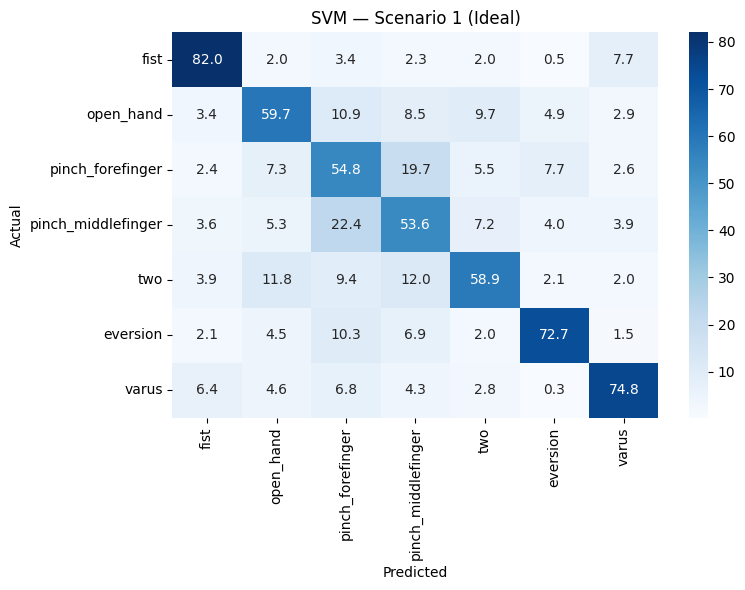

In [5]:
metrics_s1, _ = eval_svm(svm_s1, scaler_s1, X_test, y_test, title="SVM — Scenario 1 (Ideal)")

In [6]:
# Per-subject SVM evaluation (sanity check vs paper SeNic Figure 6)
from src.data_splitter import load_metadata, load_windows_from_metadata, compute_normalization_stats, apply_normalization
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

meta = load_metadata()
subset = meta[(meta["session"] == 0) & (meta["position"] == 0)]

per_subject_acc = {}
for subj in sorted(subset["subject"].unique()):
    subj_df = subset[subset["subject"] == subj]
    train_df = subj_df[subj_df["repetition"].isin([0, 1])]
    test_df = subj_df[subj_df["repetition"] == 2]

    X_tr, y_tr = load_windows_from_metadata(train_df, verbose=False)
    X_te, y_te = load_windows_from_metadata(test_df, verbose=False)

    mean, std = compute_normalization_stats(X_tr)
    X_tr = apply_normalization(X_tr, mean, std)
    X_te = apply_normalization(X_te, mean, std)

    F_tr = extract_features_batch(X_tr)
    F_te = extract_features_batch(X_te)
    sc = StandardScaler().fit(F_tr)
    F_tr, F_te = sc.transform(F_tr), sc.transform(F_te)

    m = SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_SEED)
    m.fit(F_tr, y_tr)
    per_subject_acc[subj] = accuracy_score(y_te, m.predict(F_te))

accs = list(per_subject_acc.values())
print(f"Per-subject accuracy: mean={np.mean(accs):.4f}, min={np.min(accs):.4f}, max={np.max(accs):.4f}")
print()
for subj, acc in sorted(per_subject_acc.items()):
    bar = "█" * int(acc * 40)
    print(f"  {subj:4s}: {acc:.3f} {bar}")

Per-subject accuracy: mean=0.7768, min=0.5933, max=0.9087

  h0  : 0.849 █████████████████████████████████
  h1  : 0.593 ███████████████████████
  h10 : 0.865 ██████████████████████████████████
  h11 : 0.624 ████████████████████████
  h12 : 0.698 ███████████████████████████
  h13 : 0.705 ████████████████████████████
  h14 : 0.890 ███████████████████████████████████
  h15 : 0.786 ███████████████████████████████
  h16 : 0.796 ███████████████████████████████
  h17 : 0.667 ██████████████████████████
  h18 : 0.793 ███████████████████████████████
  h19 : 0.841 █████████████████████████████████
  h2  : 0.738 █████████████████████████████
  h20 : 0.687 ███████████████████████████
  h21 : 0.863 ██████████████████████████████████
  h22 : 0.821 ████████████████████████████████
  h23 : 0.845 █████████████████████████████████
  h24 : 0.809 ████████████████████████████████
  h25 : 0.782 ███████████████████████████████
  h26 : 0.646 █████████████████████████
  h27 : 0.650 █████████████████████████
  

In [7]:
# Save model
joblib.dump({"model": svm_s1, "scaler": scaler_s1}, MODELS_DIR / "svm_s1_ideal.pkl")
print("Saved.")

Saved.


---
## Scenario 2 — Electrode Shift (per-position curve)

In [8]:
X_train_s2, y_train_s2, test_by_pos, info_s2 = scenario_2_per_position()
print(f"Train: {X_train_s2.shape}")
print(f"Test positions: {list(test_by_pos.keys())}")

Loading windows: 100%|██████████| 629/629 [00:00<00:00, 1876.02it/s]


Train: (71927, 8, 50)
Test positions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [9]:
svm_s2, scaler_s2 = train_svm(X_train_s2, y_train_s2, tune=True)

Subsampled to 50000 (SVM scalability limit)
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params: {'C': 100, 'gamma': 0.01}, CV acc: 0.8766


Position  1: acc = 0.3203
Position  2: acc = 0.2198
Position  3: acc = 0.1931
Position  4: acc = 0.1846
Position  5: acc = 0.1812
Position  6: acc = 0.2115
Position  7: acc = 0.3247
Position  8: acc = 0.4026
Position  9: acc = 0.1753
Position 10: acc = 0.1862


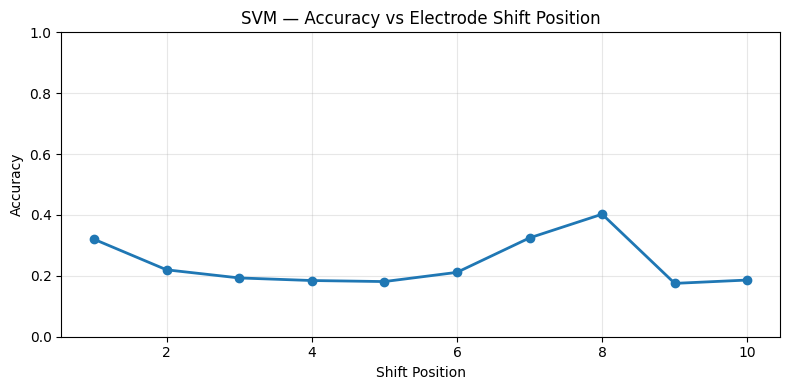

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

acc_per_pos = {}
for pos, (X_pos, y_pos) in sorted(test_by_pos.items()):
    F_pos = scaler_s2.transform(extract_features_batch(X_pos))
    y_pred = svm_s2.predict(F_pos)
    acc_per_pos[pos] = accuracy_score(y_pos, y_pred)
    print(f"Position {pos:2d}: acc = {acc_per_pos[pos]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_pos.keys()), list(acc_per_pos.values()), "o-", linewidth=2)
plt.xlabel("Shift Position")
plt.ylabel("Accuracy")
plt.title("SVM — Accuracy vs Electrode Shift Position")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(Path(sys.path[0]) / "results" / "figures" / "svm_shift_curve.png"), dpi=150)
plt.show()

In [24]:
# S2b — Calibration setup (train p0,p3,p6, test remaining)
from src.data_splitter import load_metadata, load_windows_from_metadata, compute_normalization_stats, apply_normalization
from config import SUBJECTS_NON_FATIGUE

meta = load_metadata()
subset = meta[(meta["session"] == 0) & (meta["subject"].isin(SUBJECTS_NON_FATIGUE))]

TRAIN_POS = [0, 3, 6]
TEST_POS = [p for p in range(11) if p not in TRAIN_POS]

train_df = subset[subset["position"].isin(TRAIN_POS)]
test_df = subset[subset["position"].isin(TEST_POS)]

X_tr, y_tr = load_windows_from_metadata(train_df)
mean, std = compute_normalization_stats(X_tr)
X_tr = apply_normalization(X_tr, mean, std)

svm_s2b, scaler_s2b = train_svm(X_tr, y_tr, tune=False)

acc_s2b = {}
for pos in TEST_POS:
    pos_df = subset[subset["position"] == pos]
    X_p, y_p = load_windows_from_metadata(pos_df, verbose=False)
    X_p = apply_normalization(X_p, mean, std)
    F_p = scaler_s2b.transform(extract_features_batch(X_p))
    y_pred = svm_s2b.predict(F_p)
    acc_s2b[pos] = accuracy_score(y_p, y_pred)
    print(f"Position {pos:2d}: acc = {acc_s2b[pos]:.4f}")

print(f"\nSVM S2 calibration avg: {np.mean(list(acc_s2b.values())):.4f}")

Loading windows: 100%|██████████| 1887/1887 [00:00<00:00, 2217.13it/s]


Subsampled to 50000 (SVM scalability limit)
Position  1: acc = 0.2903
Position  2: acc = 0.3251
Position  4: acc = 0.3023
Position  5: acc = 0.3537
Position  7: acc = 0.3685
Position  8: acc = 0.3730
Position  9: acc = 0.3256
Position 10: acc = 0.3546

SVM S2 calibration avg: 0.3366


In [11]:
joblib.dump({"model": svm_s2, "scaler": scaler_s2}, MODELS_DIR / "svm_s2_shift.pkl")
print("Saved.")

Saved.


---
## Scenario 3 — Inter-Subject

In [12]:
X_train_s3, y_train_s3, X_test_s3, y_test_s3, info_s3 = scenario_3_inter_subject()
print(f"Train: {X_train_s3.shape} ({len(info_s3['train_subjects'])} subjects)")
print(f"Test:  {X_test_s3.shape} ({info_s3['test_subjects']})")

Loading windows: 100%|██████████| 1385/1385 [00:00<00:00, 1520.11it/s]


Train: (618926, 8, 50) (24 subjects)
Test:  (168232, 8, 50) (['h7', 'h22', 'h3', 'h24', 'h16', 'h17'])


In [13]:
svm_s3, scaler_s3 = train_svm(X_train_s3, y_train_s3, tune=False)  # skip tune, dataset large

Subsampled to 50000 (SVM scalability limit)



  SVM — Scenario 3 (Inter-Subject)
  Accuracy:  0.4027
  F1-macro:  0.4005
                    precision    recall  f1-score   support

              fist       0.43      0.39      0.41     23888
         open_hand       0.34      0.39      0.36     23933
  pinch_forefinger       0.32      0.28      0.30     24284
pinch_middlefinger       0.29      0.27      0.28     24064
               two       0.47      0.46      0.47     23897
          eversion       0.56      0.61      0.58     24069
             varus       0.39      0.42      0.40     24097

          accuracy                           0.40    168232
         macro avg       0.40      0.40      0.40    168232
      weighted avg       0.40      0.40      0.40    168232



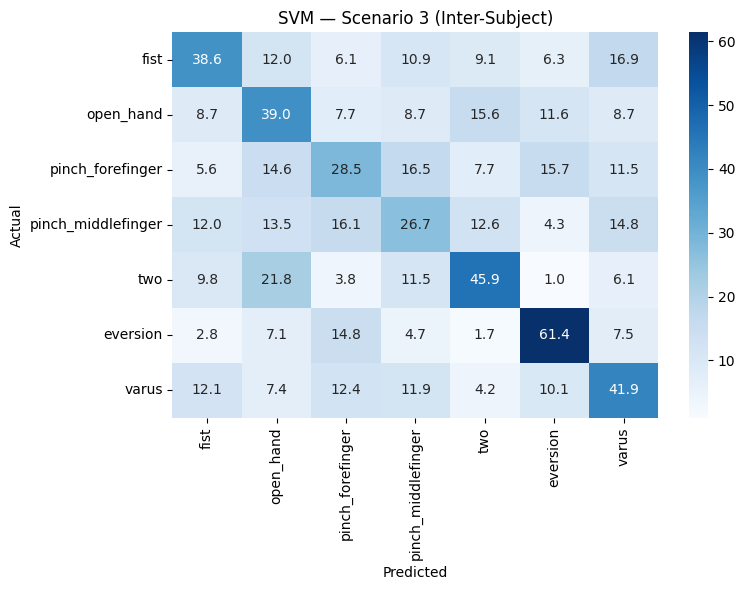

In [14]:
metrics_s3, _ = eval_svm(svm_s3, scaler_s3, X_test_s3, y_test_s3, title="SVM — Scenario 3 (Inter-Subject)")

In [15]:
joblib.dump({"model": svm_s3, "scaler": scaler_s3}, MODELS_DIR / "svm_s3_intersubject.pkl")
print("Saved.")

Saved.


---
## Scenario 4 — Inter-Day

In [16]:
X_train_s4, y_train_s4, test_by_sess, info_s4 = scenario_4_interday()
print(f"Train: {X_train_s4.shape}")
print(f"Test sessions: {list(test_by_sess.keys())}")

Loading windows: 100%|██████████| 126/126 [00:00<00:00, 915.98it/s]


Train: (13445, 8, 50)
Test sessions: [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [17]:
svm_s4, scaler_s4 = train_svm(X_train_s4, y_train_s4, tune=False)

Session 1: acc = 0.5936
Session 2: acc = 0.6613
Session 3: acc = 0.6555
Session 4: acc = 0.6520
Session 5: acc = 0.6088
Session 6: acc = 0.6564
Session 7: acc = 0.6239
Session 8: acc = 0.6638
Session 9: acc = 0.5573


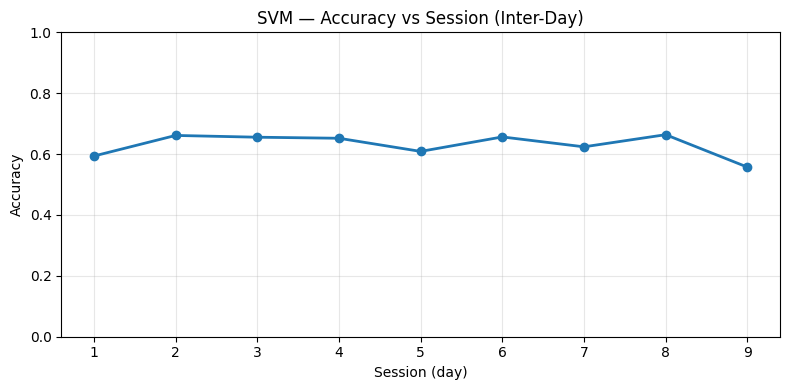

In [18]:
acc_per_sess = {}
for sess, (X_s, y_s) in sorted(test_by_sess.items()):
    F_s = scaler_s4.transform(extract_features_batch(X_s))
    y_pred = svm_s4.predict(F_s)
    acc_per_sess[sess] = accuracy_score(y_s, y_pred)
    print(f"Session {sess}: acc = {acc_per_sess[sess]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_sess.keys()), list(acc_per_sess.values()), "o-", linewidth=2)
plt.xlabel("Session (day)")
plt.ylabel("Accuracy")
plt.title("SVM — Accuracy vs Session (Inter-Day)")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(Path(sys.path[0]) / "results" / "figures" / "svm_interday_curve.png"), dpi=150)
plt.show()

---
## Scenario 5 — Fatigue

In [19]:
X_train_s5, y_train_s5, test_by_fatigue, info_s5 = scenario_5_fatigue()
print(f"Train: {X_train_s5.shape}")
print(f"Test positions: {list(test_by_fatigue.keys())}")

Loading windows: 100%|██████████| 252/252 [00:00<00:00, 1541.15it/s]


Train: (33046, 8, 50)
Test positions: [2, 3, 4, 5, 6, 7, 8, 9, 10]


In [20]:
svm_s5, scaler_s5 = train_svm(X_train_s5, y_train_s5, tune=False)

Position  2: acc = 0.8189
Position  3: acc = 0.8101
Position  4: acc = 0.8167
Position  5: acc = 0.8334
Position  6: acc = 0.8180
Position  7: acc = 0.8242
Position  8: acc = 0.7905
Position  9: acc = 0.7968
Position 10: acc = 0.7992


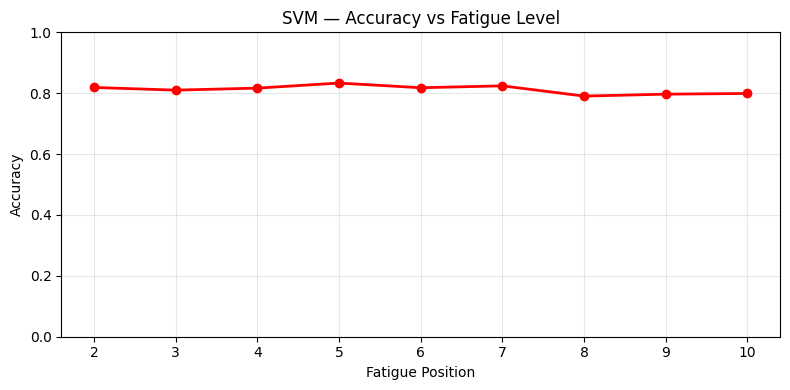

In [21]:
acc_per_fatigue = {}
for pos, (X_p, y_p) in sorted(test_by_fatigue.items()):
    F_p = scaler_s5.transform(extract_features_batch(X_p))
    y_pred = svm_s5.predict(F_p)
    acc_per_fatigue[pos] = accuracy_score(y_p, y_pred)
    print(f"Position {pos:2d}: acc = {acc_per_fatigue[pos]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_fatigue.keys()), list(acc_per_fatigue.values()), "o-", linewidth=2, color="red")
plt.xlabel("Fatigue Position")
plt.ylabel("Accuracy")
plt.title("SVM — Accuracy vs Fatigue Level")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(Path(sys.path[0]) / "results" / "figures" / "svm_fatigue_curve.png"), dpi=150)
plt.show()

---
## Latency Measurement

In [22]:
# End-to-end latency: feature extraction + scaler + predict for 1 window
sample_window = X_train[:1]  # shape (1, 8, 50)

def svm_predict_single(x):
    f = extract_features_batch(x)
    f = scaler_s1.transform(f)
    return svm_s1.predict(f)

latency = measure_latency(svm_predict_single, sample_window, n_runs=500)
print_latency(latency, model_name="SVM (feature extract + predict)")


Latency — SVM (feature extract + predict)
  Mean:   5.22 ms
  Median: 5.28 ms
  P95:    5.40 ms
  <300ms: ✓


---
## Summary

In [23]:
print("\n" + "=" * 50)
print("SVM BASELINE — ALL SCENARIOS")
print("=" * 50)
print(f"S1 Ideal:         acc = {metrics_s1['accuracy']:.4f}, f1 = {metrics_s1['f1_macro']:.4f}")
print(f"S2 Shift (avg):   acc = {np.mean(list(acc_per_pos.values())):.4f}")
print(f"S3 Inter-subject: acc = {metrics_s3['accuracy']:.4f}, f1 = {metrics_s3['f1_macro']:.4f}")
print(f"S4 Inter-day (avg): acc = {np.mean(list(acc_per_sess.values())):.4f}")
print(f"S5 Fatigue (avg): acc = {np.mean(list(acc_per_fatigue.values())):.4f}")
print(f"Latency (p95):    {latency['p95_ms']:.2f} ms")
print("=" * 50)


SVM BASELINE — ALL SCENARIOS
S1 Ideal:         acc = 0.6519, f1 = 0.6550
S2 Shift (avg):   acc = 0.2399
S3 Inter-subject: acc = 0.4027, f1 = 0.4005
S4 Inter-day (avg): acc = 0.6303
S5 Fatigue (avg): acc = 0.8120
Latency (p95):    5.40 ms
